In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [13]:
data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [27]:
data = np.array(data)
m, n = data.shape
np.random.shuffle(data)
#divide dev set
data_dev = data[0:1000].T
y_dev = data_dev[0]
x_dev = data_dev[0:n]

#divide train set
data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.   #normalize

In [28]:
Y_train

array([2, 2, 2, ..., 5, 5, 9])

In [30]:
X_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [50]:
def init_params():
    W1 = np.random.rand(10, 784) * 0.01
    b1 = np.random.rand(10, 1)            
    W2 = np.random.rand(10, 10)               
    b2 = np.random.rand(10, 1) 
    return W1, b1, W2, b2

# 784 (pixels)
#       ↓
# 10 neurons (Hidden layer)
#       ↓
# 10 neurons (Output layer)

def ReLU(Z):
    return np.maximum(Z, 0)     # FOR Non-linearity

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2
    
def ReLU_deriv(Z):               #FOR Backpropagation
    return Z > 0

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2
    


In [51]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 10 == 0:
            print("Iteration: ", i)
            predictions = get_predictions(A2)
            print("Accuracy: ", get_accuracy(predictions, Y))
    return W1, b1, W2, b2


# Forward Propagation
# ↓
# Loss
# ↓
# Backpropagation
# ↓
# Gradient Descent

In [53]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteration:  0
[0 0 0 ... 0 0 0] [8 3 4 ... 2 3 2]
Accuracy:  0.09841463414634147
Iteration:  10
[7 0 6 ... 6 0 2] [8 3 4 ... 2 3 2]
Accuracy:  0.4383658536585366
Iteration:  20
[7 0 6 ... 6 0 2] [8 3 4 ... 2 3 2]
Accuracy:  0.5653170731707317
Iteration:  30
[8 2 6 ... 6 0 2] [8 3 4 ... 2 3 2]
Accuracy:  0.716390243902439
Iteration:  40
[8 3 6 ... 6 0 2] [8 3 4 ... 2 3 2]
Accuracy:  0.7847560975609756
Iteration:  50
[8 3 4 ... 6 3 2] [8 3 4 ... 2 3 2]
Accuracy:  0.8098048780487805
Iteration:  60
[8 3 4 ... 6 3 2] [8 3 4 ... 2 3 2]
Accuracy:  0.8236585365853658
Iteration:  70
[8 3 4 ... 6 3 2] [8 3 4 ... 2 3 2]
Accuracy:  0.8347073170731707
Iteration:  80
[8 3 4 ... 6 3 2] [8 3 4 ... 2 3 2]
Accuracy:  0.8434634146341463
Iteration:  90
[8 3 4 ... 6 3 2] [8 3 4 ... 2 3 2]
Accuracy:  0.8502682926829268
Iteration:  100
[8 3 4 ... 6 3 2] [8 3 4 ... 2 3 2]
Accuracy:  0.8555853658536585
Iteration:  110
[8 3 4 ... 6 3 2] [8 3 4 ... 2 3 2]
Accuracy:  0.8604146341463415
Iteration:  120
[8 3 4 ... 

In [58]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [9]
Label:  9


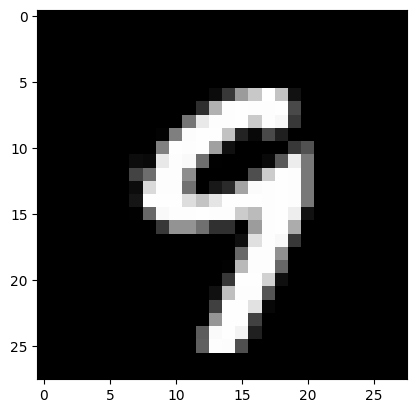

In [60]:
test_prediction(5, W1, b1, W2, b2)

Prediction:  [8]
Label:  8


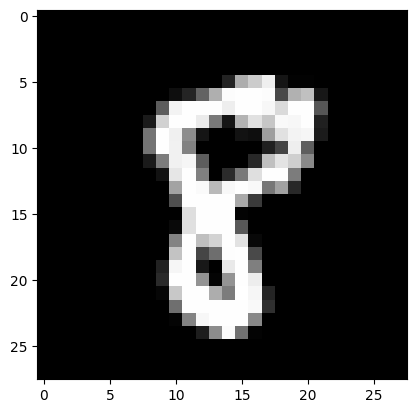

In [62]:
test_prediction(0, W1, b1, W2, b2)

Prediction:  [6]
Label:  6


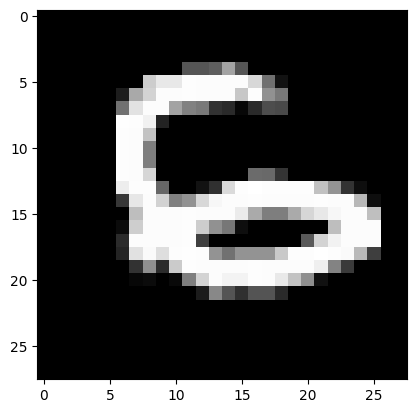

In [64]:
test_prediction(3, W1, b1, W2, b2)